# MS Proteomics x mulink

In this tutorial, we integrate real-world proteomics data with mulink. MS-proteomics data represent a natural usecase for the graph-like representation of feature relationships: 

In MS-proteomics biologically meaningful protein intensities represent a inferred measurement from the observed measurements of charged peptides (precursors) that were generated via tryptic digests from proteins. Multiple precursors can be derived from a single protein (N precursors map to 1 protein). Due to sequence homology, a precursor might also be derived from different proteins (1 precursor might map to M proteins). This corresponds to a N:M mapping that can be represented as graph. 

![](../_static/_assets/proteomics-data.png)


In MS-proteomics kind of hierarchical quantification data is typically stored in peptide-spectrum match (PSM) tables. They contain information about the inferred intensities of all feature levels (precursors, peptides, proteins) and are typically stored as a huge table in long format.

To learn more about PSM tables, have a look at [this tutorial in the alphabase package](https://alphabase.readthedocs.io/en/latest/nbs/psm_readers.html#PSM-readers). 

In [1]:
# ! pip install alphapepttools

In [2]:
import alphapepttools as apt
import mudata as md
import networkx as nx
import pandas as pd

from alphabase.psm_reader import psm_reader_provider
from alphapepttools.io.reader_columns import FEATURE_LEVEL_CONFIG
from typing import Literal
import mulink  # noqa
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

## Approach

In this tutorial, we will use the python package [`alphapepttools`](https://github.com/MannLabs/alphapepttools.git) to read the different feature levels (precursor and proteins) into mulink from a real-world proteomics dataset stored as PSM table

The following functions construct a `mudata` object from the different relevant feature levels (here: genes, proteins, precursors). Here, `alphapepttools` takes care of reading in the actual data from the search result via the function `alphapepttools.io.read_psm_table`, which natively maps the outputs from various search engines to standardized column names. `alphapepttools` "knows" which columns are relevant for a specific feature level via its `FEATURE_LEVEL_CONFIG` 

The key step is to construct the `mulink`-compatible adjacency matrix from the PSM report. This is done by the function `sparse_matrix_mapping`, that leverages `networkx` to convert the implicit feature mapping in the PSM report to an adjacency matrix. Note that it is important to align the feature order in the adjacency matrix and the constructed mudata object!

In [3]:
ALPHAPEPTTOOLS_FEATURE_ID_NAME = "feature_id_column"


def sparse_matrix_mapping(
    mapping_df: pd.DataFrame, columns: list[str] | None = None, *, transitive_closure: bool = True
) -> pd.DataFrame:
    """Create a square sparse adjacency matrix for varp from a vertix mapping.

    Parameters
    ----------
    mapping_df : pd.DataFrame
        DataFrame encoding the edges between source vertices and target vertices.
    kwargs
        Passed to :func:`nx.from_pandas_edgelist`

    Returns
    -------
    Dataframe representing the adjacency matrix of the respective directed acylic graph.
    Directed graph in which source vertices are pointing towards target vertices.
    The semantics of the edges depend on the application
    """
    columns = mapping_df.columns if columns is None else columns

    full_dag = nx.DiGraph()
    for idx in tqdm(range(len(columns) - 1)):
        dag = nx.from_pandas_edgelist(mapping_df, source=columns[idx], target=columns[idx + 1], create_using=nx.DiGraph)
        full_dag = nx.compose(full_dag, dag)

    if transitive_closure:
        full_dag = nx.transitive_closure_dag(full_dag)

    return pd.DataFrame.sparse.from_spmatrix(
        nx.to_scipy_sparse_array(full_dag), index=full_dag.nodes, columns=full_dag.nodes
    )


def reindex_adjacency(df: pd.DataFrame, new_index: pd.Index) -> csr_matrix:
    """Reindex a sparse adjacency-matrix DataFrame to `new_index` along both axes

    Labels in `new_index` not present in `df.index` become all-zero
    rows/columns (implicit, costing no memory). Labels in `df.index` not
    present in `new_index` are dropped.

    Assumes `df.index.equals(df.columns)` and unique labels.
    """
    if not df.index.equals(df.columns):
        raise ValueError("Adjacency DataFrame must have matching index and columns")
    if not df.index.is_unique:
        raise ValueError("Adjacency index must be unique")

    # Map each position in new_index to a position in df.index (-1 if missing).
    indexer = df.index.get_indexer(new_index)
    keep = indexer >= 0
    src = indexer[keep]  # positions to take from the original
    dst = np.flatnonzero(keep)  # where they land in the new matrix

    # Pull out the submatrix corresponding to nodes that survive.
    # CSR for row slicing, then CSC for column slicing — each is O(nnz of
    # the selected slice) rather than scanning the whole matrix.
    mat = df.sparse.to_coo().tocsr()
    sub = mat[src, :].tocsc()[:, src].tocoo()

    # Remap the submatrix's local (row, col) into positions in new_index.
    n = len(new_index)

    return csr_matrix(
        (sub.data, (dst[sub.row], dst[sub.col])),
        shape=(n, n),
        dtype=mat.dtype,
    )


def prot_to_mulink(
    psm_path: str,
    feature_level_names: list[Literal["proteins", "precursor", "peptides", "genes"]],
    search_engine: str,
    *,
    transitive_closure: bool = True,
) -> md.MuData:
    """Create a mulink-compatible mudata object from a search engine peptide spectrum match table

    Parameters
    ----------
    psm_path
        Path to search engine file
    feature_level_names
        List of column names in the PSM table that represent the feature levels to map.
        Have to be passed in the hierarchical order of the layers.
        e.g. precursors > peptides > proteins > genes
    search_engine
        Search engine that produced the PSM table. See `alphapepttools.io.available_reader(kind="psm")` for a list of supported outputs
    transitive_closure
        Whether implicit links should be made explicit.

    Returns
    -------
    mudata object with mulink
    """
    adatas = {}
    for feature_level in tqdm(feature_level_names):
        # TODO: replace with AnnDataFactory when it supports recreation of level-specific results
        adatas[feature_level] = apt.io.read_psm_table(psm_path, search_engine=search_engine, level=feature_level)

    reader = psm_reader_provider.get_reader(reader_type=search_engine)
    psm = reader.load(psm_path)

    adjancency_matrix = sparse_matrix_mapping(
        psm,
        # use the feature_id columns in the PSM table
        columns=[
            FEATURE_LEVEL_CONFIG[feature_level][ALPHAPEPTTOOLS_FEATURE_ID_NAME] for feature_level in feature_level_names
        ],
        transitive_closure=transitive_closure,
    )

    mdata = md.MuData(data=adatas)
    # IMPORTANT: features in the adjacency matrix need to be aligned with the variable order in the mdata object
    adjancency_matrix = reindex_adjacency(adjancency_matrix, new_index=mdata.var_names)
    mdata.link.add_link(adjancency_matrix)

    return mdata

## Construction

We use an example DIANN report which is an example dataset in alphapepttools. 

In [4]:
psm_report = apt.data.get_data("pelsa_report_diann")

/Users/lucas-diedrich/Documents/Projects/scverse/mulink/mulink/docs/notebooks/report.parquet already exists (70.8467435836792 MB)


In [5]:
mdata = prot_to_mulink(
    psm_path=psm_report,
    search_engine="diann",
    feature_level_names=["precursor", "proteins", "genes"],
    transitive_closure=True,
)
mdata

100%|██████████| 2/2 [00:01<00:00,  1.20it/s]
/Users/lucas-diedrich/mamba/envs/mulink/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/mulink/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 8 × 106642
  varp:	'feature_mapping'
  3 modalities
    precursor:	8 × 91803
    proteins:	8 × 7523
    genes:	8 × 7316

## Analysis

Now we can find and plot all precursors that map to a specific protein. Let's have a look at `P11802` (Cyclin-dependent Kinase 4). We see that multiple precursors (peptides with different charge states) map to the protein, including an acetylated peptide. 

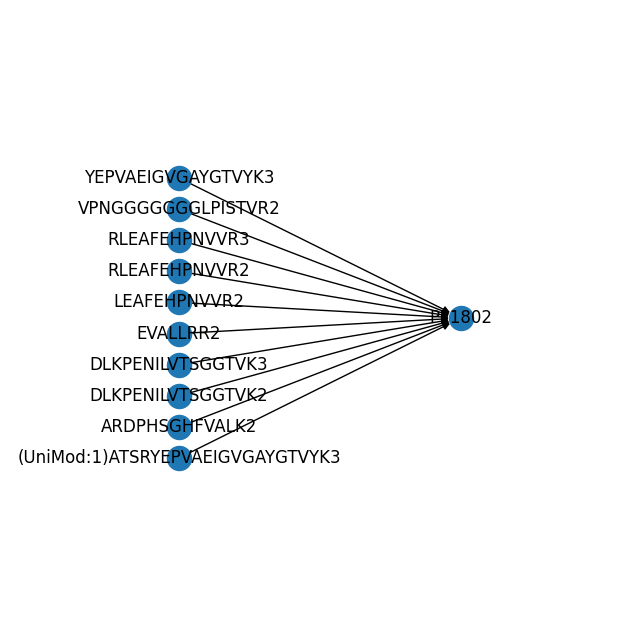

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
(mdata.link.query.ancestors("P11802").link.pl.graph(with_labels=True, ax=ax))
plt.margins(0.5)
plt.show()

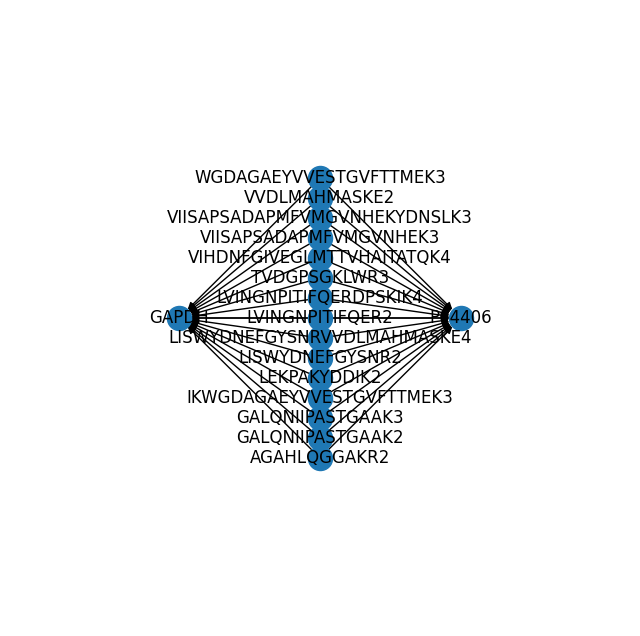

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
(mdata.link.query.ancestors("GAPDH").link.pl.graph(with_labels=True, ax=ax))
plt.margins(0.5)
plt.show()

## References

We use [alphapepttools](https://github.com/MannLabs/alphapepttools.git), [alphabase](https://github.com/MannLabs/alphabase.git), and [mudata](https://github.com/scverse/mudata.git) in this tutorial. 
> Brennsteiner, V., Ben-Moshe, S., Diedrich, L., Mann, M., & Schwörer, M. alphapepttools [Computer software]. https://github.com/MannLabs/alphapepttools

> Zeng, W.-F. et al. AlphaPeptDeep: a modular deep learning framework to predict peptide properties for proteomics. Nat Commun 13, 7238 (2022).

> MUON: multimodal omics analysis framework Danila Bredikhin, Ilia Kats, Oliver Stegle Genome Biology 2022 Feb 01. doi: 10.1186/s13059-021-02577-8.


The utilized dataset was downloaded from [PRIDE](http://proteomecentral.proteomexchange.org/cgi/GetDataset?ID=PXD034606) and was generated in the following study:
> Li, Kejia, et al. A peptide-centric local stability assay enables proteome-scale identification of the protein targets and binding regions of diverse ligands. Nature Methods 22.2 (2025): 278-282.	

Similar data structures for MS-proteomics data are available in the QFeatures package in R

> Gatto L, Vanderaa C (2026). QFeatures: Quantitative features for mass spectrometry data. doi:10.18129/B9.bioc.QFeatures. R package version 1.22.0, https://bioconductor.org/packages/QFeatures.


An initial proof-of-principle implementation of a DIANN reader to mulink was spearheaded [by Marvin Thielert and Charu Sharma](../about.md). 